# PyKEEN KGE Benchmark Case Study

This notebook compares four knowledge graph embedding models in a controlled PyKEEN setup:

- `TransE`
- `PairRE`
- `DistMult`
- `ConvE`

The notebook supports two benchmark modes:

- `minimal`: a small and fast benchmark on `Nations`
- `complete`: a broader benchmark on larger datasets with much longer training times

Both modes keep the data split and evaluation protocol fixed within each dataset and compare:

- Mean Reciprocal Rank (`MRR`)
- `Hits@1`, `Hits@3`, `Hits@10`
- training time
- parameter count

The checked-in notebook is intended to be re-runnable. By default it uses the `minimal` mode because `complete` takes much longer.


## Standalone implementation

The notebook contains the full benchmark implementation below, so it can be run without importing `benchmark_case_study.py`.


### Imports

These imports load plotting/dataframe utilities, PyKEEN datasets, and the PyKEEN pipeline API used for training and evaluation.


In [1]:
import json
import logging
import traceback
import warnings
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from pykeen.datasets import (
    CoDExSmall,
    Countries,
    DBpedia50,
    FB15k237,
    Kinships,
    Nations,
    UMLS,
)
from pykeen.pipeline import pipeline

plt.style.use('seaborn-v0_8-whitegrid')


### Benchmark configuration

The registry maps dataset names to PyKEEN dataset classes, and the two presets define the fixed datasets, models, and hyperparameters used throughout the case study.


In [2]:
RESULTS_DIR = Path('results')
RANDOM_SEED = 42

DATASET_REGISTRY = {
    'CoDExSmall': CoDExSmall,
    'Countries': Countries,
    'DBpedia50': DBpedia50,
    'FB15k237': FB15k237,
    'Nations': Nations,
    'Kinships': Kinships,
    'UMLS': UMLS,
}

BENCHMARK_CONFIGS: dict[str, dict[str, Any]] = {
    'minimal': {
        'description': 'Small, fast benchmark on Nations for a compact student submission.',
        'datasets': ['Nations'],
        'embedding_dim': 64,
        'num_epochs': 30,
        'batch_size': 128,
        'learning_rate': 1e-3,
        'create_inverse_triples': True,
        'models': [
            {'model': 'TransE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'PairRE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'DistMult', 'model_kwargs': {'embedding_dim': 64}},
            {
                'model': 'ConvE',
                'model_kwargs': {
                    'embedding_dim': 64,
                    'embedding_height': 8,
                    'output_channels': 16,
                },
            },
        ],
    },
    'complete': {
        'description': 'Broader 7-dataset benchmark spanning Countries, Nations, Kinships, UMLS, CoDExSmall, DBpedia50, and FB15k237 for a stronger comparison without the duplicate and heaviest datasets.',
        'datasets': [
            'Countries',
            'Nations',
            'Kinships',
            'UMLS',
            'CoDExSmall',
            'DBpedia50',
            'FB15k237',
        ],
        'embedding_dim': 64,
        'num_epochs': 50,
        'batch_size': 128,
        'learning_rate': 1e-3,
        'create_inverse_triples': True,
        'models': [
            {'model': 'TransE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'PairRE', 'model_kwargs': {'embedding_dim': 64}},
            {'model': 'DistMult', 'model_kwargs': {'embedding_dim': 64}},
            {
                'model': 'ConvE',
                'model_kwargs': {
                    'embedding_dim': 64,
                    'embedding_height': 8,
                    'output_channels': 16,
                },
            },
        ],
    },
}


### Dataset and pipeline helpers

These helpers validate the selected preset, summarize fixed train/validation/test splits, and build the shared PyKEEN pipeline arguments so every model uses the same protocol.


In [3]:
def _configure_runtime() -> None:
    warnings.filterwarnings('ignore')
    logging.getLogger('pykeen').setLevel(logging.ERROR)
    logging.getLogger('torch_max_mem').setLevel(logging.ERROR)
    logging.getLogger('pykeen.triples').setLevel(logging.ERROR)
    logging.getLogger('pykeen.training').setLevel(logging.ERROR)


def get_benchmark_config(mode: str) -> dict[str, Any]:
    try:
        return BENCHMARK_CONFIGS[mode]
    except KeyError as error:
        allowed = ', '.join(sorted(BENCHMARK_CONFIGS))
        raise ValueError(f'Unknown benchmark mode {mode!r}. Expected one of: {allowed}.') from error


def get_dataset_summaries(mode: str) -> list[dict[str, int | str]]:
    config = get_benchmark_config(mode)
    summaries: list[dict[str, int | str]] = []
    for dataset_name in config['datasets']:
        dataset = DATASET_REGISTRY[dataset_name](
            create_inverse_triples=config['create_inverse_triples']
        )
        summaries.append(
            {
                'dataset': dataset_name,
                'training_triples': dataset.training.num_triples,
                'validation_triples': dataset.validation.num_triples,
                'testing_triples': dataset.testing.num_triples,
                'entities': dataset.training.num_entities,
                'relations': dataset.training.num_relations,
            }
        )
    return summaries


def _build_pipeline_kwargs(dataset: Any, config: dict[str, Any]) -> dict[str, Any]:
    return {
        'dataset': dataset,
        'random_seed': RANDOM_SEED,
        'optimizer': 'Adam',
        'optimizer_kwargs': {'lr': config['learning_rate']},
        'negative_sampler': 'basic',
        'negative_sampler_kwargs': {'num_negs_per_pos': 1},
        'training_kwargs': {
            'num_epochs': config['num_epochs'],
            'batch_size': config['batch_size'],
            'use_tqdm': False,
        },
        'evaluator_kwargs': {
            'filtered': True,
            'batch_size': config['batch_size'],
        },
        'evaluation_kwargs': {'use_tqdm': False},
        'device': 'cpu',
    }


### Benchmark runner

This function loops over every dataset-model pair, trains with PyKEEN, records ranking metrics, training time, parameter count, and loss curves, then returns a tidy results table.


In [4]:
def run_case_study(
    mode: str = 'minimal',
) -> tuple[pd.DataFrame, dict[str, dict[str, list[float]]], list[dict[str, int | str]], dict[str, Any]]:
    _configure_runtime()
    config = get_benchmark_config(mode)
    total_runs = len(config['datasets']) * len(config['models'])
    completed_runs = 0

    print(
        f"Starting {mode} benchmark: {len(config['datasets'])} datasets x "
        f"{len(config['models'])} models, {config['num_epochs']} epochs each.",
        flush=True,
    )

    rows: list[dict[str, float | int | str]] = []
    losses: dict[str, dict[str, list[float]]] = {}

    for dataset_name in config['datasets']:
        dataset = DATASET_REGISTRY[dataset_name](
            create_inverse_triples=config['create_inverse_triples']
        )
        base_kwargs = _build_pipeline_kwargs(dataset, config)
        losses[dataset_name] = {}

        for model_config in config['models']:
            model_name = model_config['model']
            run_index = completed_runs + 1
            print(
                f'[{run_index}/{total_runs}] Running {model_name} on {dataset_name}...',
                flush=True,
            )
            started_at = perf_counter()
            try:
                result = pipeline(**base_kwargs, **model_config)
            except Exception as error:
                elapsed = perf_counter() - started_at
                print(
                    f'[{run_index}/{total_runs}] ERROR while running {model_name} on '
                    f'{dataset_name} after {elapsed:.1f}s: {error}',
                    flush=True,
                )
                traceback.print_exc()
                raise
            completed_runs += 1
            elapsed = perf_counter() - started_at
            losses[dataset_name][model_name] = [float(loss) for loss in result.losses]
            rows.append(
                {
                    'dataset': dataset_name,
                    'model': model_name,
                    'train_seconds': float(result.train_seconds),
                    'parameter_count': int(result.model.num_parameters),
                    'mrr': float(
                        result.metric_results.get_metric(
                            'both.realistic.inverse_harmonic_mean_rank'
                        )
                    ),
                    'hits@1': float(
                        result.metric_results.get_metric('both.realistic.hits_at_1')
                    ),
                    'hits@3': float(
                        result.metric_results.get_metric('both.realistic.hits_at_3')
                    ),
                    'hits@10': float(
                        result.metric_results.get_metric('both.realistic.hits_at_10')
                    ),
                }
            )
            print(
                f"[{completed_runs}/{total_runs}] Finished {model_name} on {dataset_name} "
                f"in {elapsed:.1f}s, MRR={rows[-1]['mrr']:.4f}.",
                flush=True,
            )

    results = (
        pd.DataFrame(rows)
        .sort_values(['dataset', 'mrr', 'hits@10'], ascending=[True, False, False])
        .reset_index(drop=True)
    )
    return results, losses, get_dataset_summaries(mode), config


### Artifact saving

The final helper writes the benchmark table, training losses, and metadata to `results/<mode>/` so the notebook output is reproducible and easy to inspect later.


In [5]:
def save_case_study_artifacts(
    results: pd.DataFrame,
    losses: dict[str, dict[str, list[float]]],
    dataset_summaries: list[dict[str, int | str]],
    config: dict[str, Any],
    mode: str,
    output_root: Path = RESULTS_DIR,
) -> Path:
    output_dir = output_root / mode
    output_dir.mkdir(parents=True, exist_ok=True)

    (output_dir / 'benchmark_results.csv').write_text(
        results.to_csv(index=False),
        encoding='utf-8',
    )
    (output_dir / 'training_losses.json').write_text(
        json.dumps(losses, indent=2),
        encoding='utf-8',
    )
    metadata = {
        'benchmark_mode': mode,
        'description': config['description'],
        'datasets': dataset_summaries,
        'random_seed': RANDOM_SEED,
        'embedding_dim': config['embedding_dim'],
        'num_epochs': config['num_epochs'],
        'batch_size': config['batch_size'],
        'learning_rate': config['learning_rate'],
        'create_inverse_triples': config['create_inverse_triples'],
        'models': config['models'],
        'evaluation_protocol': 'Filtered ranking evaluation on the fixed test split for each dataset.',
    }
    (output_dir / 'benchmark_metadata.json').write_text(
        json.dumps(metadata, indent=2),
        encoding='utf-8',
    )
    return output_dir


## Choose benchmark mode

Set `BENCHMARK_MODE` to one of the following:

- `minimal` for the fast student-sized benchmark on `Nations`
- `complete` for the larger seven-dataset benchmark


In [6]:
BENCHMARK_MODE = 'minimal'

In [7]:
config = get_benchmark_config(BENCHMARK_MODE)
dataset_summaries = pd.DataFrame(get_dataset_summaries(BENCHMARK_MODE))

setup = pd.DataFrame(
    [
        ('Mode', BENCHMARK_MODE),
        ('Description', config['description']),
        ('Datasets', ', '.join(config['datasets'])),
        ('Models', ', '.join(model['model'] for model in config['models'])),
        ('Random seed', RANDOM_SEED),
        ('Embedding dimension', config['embedding_dim']),
        ('Epochs', config['num_epochs']),
        ('Batch size', config['batch_size']),
        ('Learning rate', config['learning_rate']),
        ('Inverse triples', config['create_inverse_triples']),
        ('Evaluation', 'Filtered ranking metrics on each fixed test split'),
    ],
    columns=['Setting', 'Value'],
)

setup

,Setting,Value
0,Mode,minimal
1,Description,"Small, fast benchmark on Nations for a compact..."
2,Datasets,Nations
3,Models,"TransE, PairRE, DistMult, ConvE"
4,Random seed,42
5,Embedding dimension,64
6,Epochs,30
7,Batch size,128
8,Learning rate,0.001
9,Inverse triples,True


## Dataset summary

The benchmark keeps each dataset's predefined train, validation, and test split fixed.


In [8]:
dataset_summaries

,dataset,training_triples,validation_triples,testing_triples,entities,relations
0,Nations,1592,199,201,14,110


## Run benchmark

This cell trains all selected models for the chosen benchmark mode and saves artifacts to `results/<mode>/`.


In [9]:
results, losses, dataset_summaries_list, config = run_case_study(mode=BENCHMARK_MODE)
output_dir = save_case_study_artifacts(
    results=results,
    losses=losses,
    dataset_summaries=dataset_summaries_list,
    config=config,
    mode=BENCHMARK_MODE,
)

print(f'Saved artifacts to {output_dir}')
results.head()

Starting minimal benchmark: 1 datasets x 4 models, 30 epochs each.


[1/4] Running TransE on Nations...


[1/4] Finished TransE on Nations in 4.8s, MRR=0.3402.


[2/4] Running PairRE on Nations...


[2/4] Finished PairRE on Nations in 4.0s, MRR=0.6989.


...

[3/4] Finished DistMult on Nations in 3.8s, MRR=0.6712.


[4/4] Running ConvE on Nations...


[4/4] Finished ConvE on Nations in 10.7s, MRR=0.6876.


Saved artifacts to results/minimal


,dataset,model,train_seconds,parameter_count,mrr,hits@1,hits@3,hits@10
0,Nations,PairRE,3.945040,14976,0.698927,0.544776,0.830846,0.985075
1,Nations,ConvE,10.635807,94352,0.687627,0.542289,0.773632,0.985075
2,Nations,DistMult,3.740712,7936,0.671206,0.524876,0.768657,0.967662
3,Nations,TransE,3.806877,7936,0.340164,0.000000,0.562189,0.972637


In [10]:
results_rounded = results.copy()
for column in ['train_seconds', 'mrr', 'hits@1', 'hits@3', 'hits@10']:
    results_rounded[column] = results_rounded[column].round(4)
results_rounded

,dataset,model,train_seconds,parameter_count,mrr,hits@1,hits@3,hits@10
0,Nations,PairRE,3.9450,14976,0.6989,0.5448,0.8308,0.9851
1,Nations,ConvE,10.6358,94352,0.6876,0.5423,0.7736,0.9851
2,Nations,DistMult,3.7407,7936,0.6712,0.5249,0.7687,0.9677
3,Nations,TransE,3.8069,7936,0.3402,0.0000,0.5622,0.9726


## Aggregate comparison

For the complete benchmark, it helps to average the results across datasets to see which model is strongest overall.


In [11]:
summary_by_model = (
    results.groupby('model', as_index=False)
    .agg(
        mean_train_seconds=('train_seconds', 'mean'),
        mean_parameter_count=('parameter_count', 'mean'),
        mean_mrr=('mrr', 'mean'),
        mean_hits_at_1=('hits@1', 'mean'),
        mean_hits_at_3=('hits@3', 'mean'),
        mean_hits_at_10=('hits@10', 'mean'),
    )
    .sort_values('mean_mrr', ascending=False)
    .reset_index(drop=True)
)

summary_by_model.round(4)

,model,mean_train_seconds,mean_parameter_count,mean_mrr,mean_hits_at_1,mean_hits_at_3,mean_hits_at_10
0,PairRE,3.9450,14976.0,0.6989,0.5448,0.8308,0.9851
1,ConvE,10.6358,94352.0,0.6876,0.5423,0.7736,0.9851
2,DistMult,3.7407,7936.0,0.6712,0.5249,0.7687,0.9677
3,TransE,3.8069,7936.0,0.3402,0.0000,0.5622,0.9726


## Quality comparison

The plots below compare ranking quality. In complete mode, each dataset gets its own panel so the comparison stays easy to read.


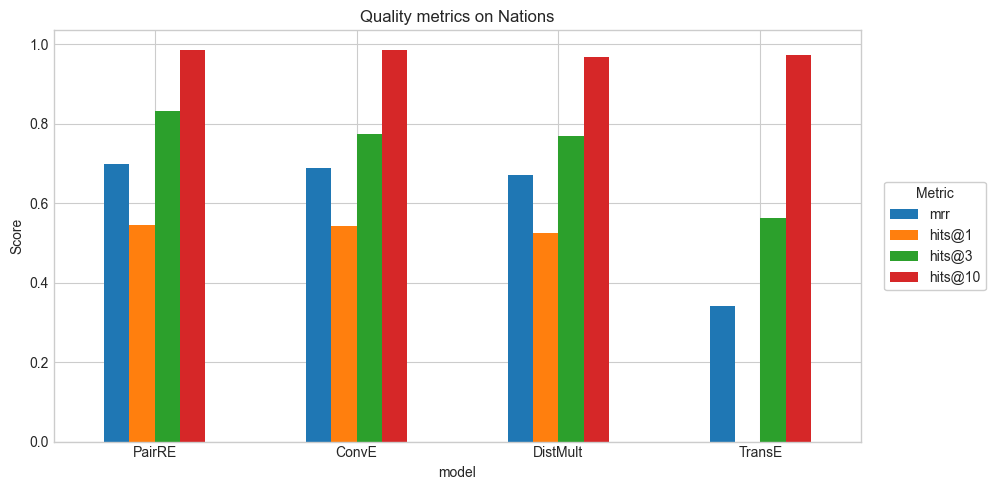

In [12]:
metric_columns = ['mrr', 'hits@1', 'hits@3', 'hits@10']
datasets = list(results['dataset'].unique())
fig, axes = plt.subplots(len(datasets), 1, figsize=(12, 5 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    ax = axes[row_index, 0]
    subset = results.loc[results['dataset'] == dataset_name].set_index('model')[metric_columns]
    subset.plot(kind='bar', ax=ax, rot=0, title=f'Quality metrics on {dataset_name}')
    ax.set_ylabel('Score')
    ax.legend(
        title='Metric',
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        facecolor='white',
        framealpha=0.95,
    )

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

## Efficiency comparison

The next plots compare training time and parameter count for each dataset.


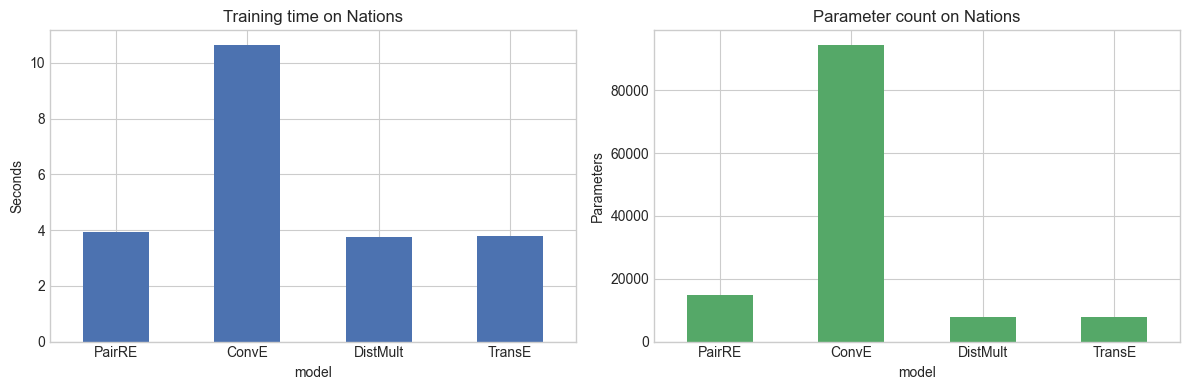

In [13]:
datasets = list(results['dataset'].unique())
fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 4 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    subset = results.loc[results['dataset'] == dataset_name]

    subset.plot(
        x='model',
        y='train_seconds',
        kind='bar',
        legend=False,
        ax=axes[row_index, 0],
        color='#4C72B0',
        rot=0,
        title=f'Training time on {dataset_name}',
    )
    axes[row_index, 0].set_ylabel('Seconds')

    subset.plot(
        x='model',
        y='parameter_count',
        kind='bar',
        legend=False,
        ax=axes[row_index, 1],
        color='#55A868',
        rot=0,
        title=f'Parameter count on {dataset_name}',
    )
    axes[row_index, 1].set_ylabel('Parameters')

plt.tight_layout()
plt.show()

## Training curves

These curves give a simple sanity check that the models trained normally under the shared epoch budget.


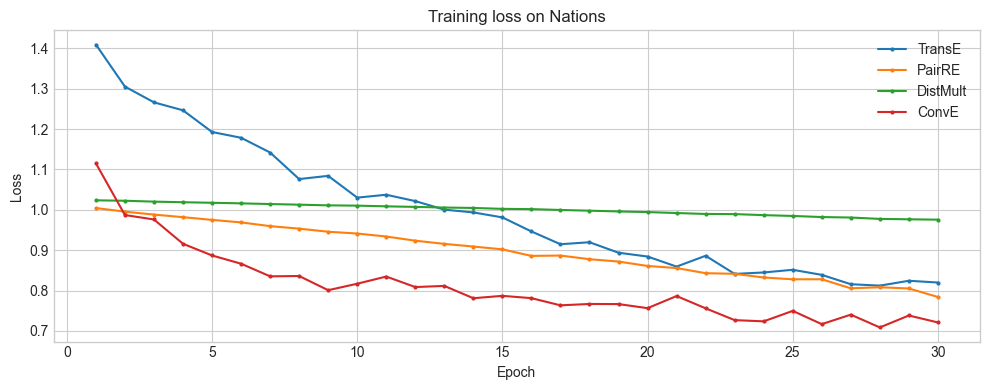

In [14]:
datasets = list(losses.keys())
fig, axes = plt.subplots(len(datasets), 1, figsize=(10, 4 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    ax = axes[row_index, 0]
    for model_name, loss_values in losses[dataset_name].items():
        epochs = range(1, len(loss_values) + 1)
        ax.plot(epochs, loss_values, marker='o', markersize=2, linewidth=1.5, label=model_name)
    ax.set_title(f'Training loss on {dataset_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## Model selection rationale

The final recommendation is based mainly on MRR, then checked against training time and parameter count.


In [15]:
best_per_dataset = (
    results.sort_values(['dataset', 'mrr', 'hits@10'], ascending=[True, False, False])
    .groupby('dataset', as_index=False)
    .first()
)

overall_best = summary_by_model.iloc[0]

lines = [
    '### Recommendation',
    '',
    f"For the selected benchmark mode, the strongest overall model is `{overall_best['model']}`.",
    '',
    f"- It has the best average MRR across the evaluated datasets: **{overall_best['mean_mrr']:.4f}**.",
    f"- Its average training time is **{overall_best['mean_train_seconds']:.2f} seconds**.",
    f"- Its average parameter count is **{int(round(overall_best['mean_parameter_count']))}**.",
    '',
    '### Best model by dataset',
    '',
]

for _, row in best_per_dataset.iterrows():
    lines.append(
        f"- `{row['dataset']}`: `{row['model']}` was best with MRR **{row['mrr']:.4f}**, "
        f"training time **{row['train_seconds']:.2f} s**, and **{int(row['parameter_count'])}** parameters."
    )

lines.extend([
    '',
    '### Short discussion',
    '',
    f"- `{overall_best['model']}` is the best final choice because it is strongest on average, not just on one dataset.",
    '- `ConvE` adds an important architectural contrast to the benchmark because it is much more expressive but also much larger.',
    '- The smaller embedding models remain useful baselines because they are easier to train and compare on efficiency.',
])

display(Markdown('\n'.join(lines)))

### Recommendation

For the selected benchmark mode, the strongest overall model is `PairRE`.

- It has the best average MRR across the evaluated datasets: **0.6989**.
- Its average training time is **3.95 seconds**.
- Its average parameter count is **14976**.

### Best model by dataset

- `Nations`: `PairRE` was best with MRR **0.6989**, training time **3.95 s**, and **14976** parameters.

### Short discussion

- `PairRE` is the best final choice because it is strongest on average, not just on one dataset.
- `ConvE` adds an important architectural contrast to the benchmark because it is much more expressive but also much larger.
- The smaller embedding models remain useful baselines because they are easier to train and compare on efficiency.

## Checked-in complete results

The default notebook run uses `minimal` mode so it stays fast to re-execute. The longer seven-dataset benchmark is already checked in under `results/complete/`; the table below summarizes those saved results without rerunning the expensive experiments.


In [16]:
complete_results_path = 'results/complete/benchmark_results.csv'
complete_results = pd.read_csv(complete_results_path)

complete_summary = (
    complete_results.groupby('model', as_index=False)
    .agg(
        mean_train_seconds=('train_seconds', 'mean'),
        mean_parameter_count=('parameter_count', 'mean'),
        mean_mrr=('mrr', 'mean'),
        mean_hits_at_1=('hits@1', 'mean'),
        mean_hits_at_3=('hits@3', 'mean'),
        mean_hits_at_10=('hits@10', 'mean'),
    )
    .sort_values('mean_mrr', ascending=False)
    .reset_index(drop=True)
)

complete_summary.round(4)


,model,mean_train_seconds,mean_parameter_count,mean_mrr,mean_hits_at_1,mean_hits_at_3,mean_hits_at_10
0,PairRE,155.6877,408859.4286,0.5081,0.3964,0.5768,0.7139
1,DistMult,164.8580,394998.8571,0.4199,0.3024,0.4796,0.6514
2,ConvE,509.8039,487356.1429,0.3355,0.2416,0.3854,0.5188
3,TransE,150.0471,394998.8571,0.2568,0.0811,0.3600,0.5729


## Conclusion

This notebook now supports both versions of the assignment:

- a `minimal` benchmark for a fast, compact submission
- a `complete` benchmark with larger datasets and longer training times for a stronger comparison

Both modes satisfy the main case study requirements: fixed evaluation protocol, multiple KGE models, quality metrics, efficiency discussion, and an explicit model choice.
